# Tutorial on Transformer Feature Visualization with CRP

This notebook shows how **Concept Relevance Propagation (CRP)** reveals what each attention head encodes in a Vision Transformer (ViT-B/16). We follow the same workflow as the [CNN feature-visualization tutorial](feature_visualization.ipynb), but swap CNN channels for transformer attention heads and `ChannelConcept` for `AttentionHeadConcept`.

**Key ideas:**
- Each attention head in a transformer layer is treated as a *concept* — a CRP interpretable unit.
- CRP finds the dataset images that maximally activate (or receive the most relevance from) each head, producing *reference images* that reveal what the head detects.
- Head specialization evolves with depth: early layers capture texture, mid layers capture shapes and parts, late layers capture class-level semantics.
- A custom `heatmap_modifier` aggregates token-level relevance into a spatial heatmap so the standard `plot_grid` pipeline works without changes.


### Table of Contents

* [1. Setup: Dependencies and Environment](#1-setup-dependencies-and-environment)
* [2. Model, Concepts, and FeatureVisualization Pipeline](#2-model-concepts-and-featurevisualization-pipeline)
    * [Monkey-patching ViT attention for LRP](#monkey-patching-vit-attention-for-lrp)
    * [Composite and Attribution](#composite-and-attribution)
    * [Attention Head Concepts and Layer Map](#attention-head-concepts-and-layer-map)
    * [FeatureVisualization Setup](#featurevisualization-setup)
* [3. Running the Analysis (Pre-computed)](#3-running-the-analysis-pre-computed)
* [4. Visualizing Attention-Head Concepts](#4-visualizing-attention-head-concepts)
    * [Late Layers — Task-Relevant Semantics](#late-layers--task-relevant-semantics)
    * [Mid Layers — Structured, Compositional Features](#mid-layers--structured-compositional-features)
    * [Early Layers — Texture and Low-Level Patterns](#early-layers--texture-and-low-level-patterns)
* [5. Class-Level Statistics](#5-class-level-statistics)


## 1. Setup: Dependencies and Environment

We import the standard PyTorch/torchvision stack plus three CRP-specific modules:
- **`crp.attribution.AttentionAttribution`** — attribution engine aware of transformer attention structure
- **`crp.concepts.AttentionHeadConcept`** — concept type that treats each attention head as a CRP unit
- **`crp.visualization.FeatureVisualization`** — orchestrates the reference-image search over the dataset
- **`crp.transformer_patches`** — monkey-patches ViT internals so that relevance flows correctly through self-attention

The notebook changes working directory to the repository root so that relative paths (e.g. `VIT_B16_ImageNet/`, `ImageNet_data/`) resolve correctly.

In [ ]:
import os

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import zennit.rules as z_rules
from torchvision.models import vision_transformer
from zennit.composites import LayerMapComposite


# Setup environment
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Navigate to repo root
os.chdir("..")
print(f"Working directory: {os.getcwd()}")

# Import CRP modules
from crp.attribution import AttentionAttribution
from crp.concepts import AttentionHeadConcept
from crp.helper import get_layer_names
from crp.visualization import FeatureVisualization

from crp.transformer_patches import monkey_patch, monkey_patch_zennit

Device: cpu
Working directory: /home/satou/Projects/crp-experimenting


## 2. Model, Concepts, and FeatureVisualization Pipeline

Setting up CRP for a transformer requires a few more steps than for a CNN. This section walks through each one.

### Monkey-patching ViT attention for LRP

Standard PyTorch `MultiheadAttention` is not differentiable in the way LRP/CRP requires: the softmax attention weights create a non-linear coupling between queries and values that breaks naive relevance propagation.

`monkey_patch(vision_transformer)` replaces the `GELU`, `LayerNorm`, and `MultiheadAttention` forward/backward kernels with LRP-compatible alternatives from the [LRP eXplains Transformers (LXT)](https://github.com/rachtibat/LRP-eXplains-Transformers) library. `monkey_patch_zennit()` then adjusts the zennit hook to work with the patched operations.

> **Note:** This patch modifies the `torchvision.models.vision_transformer` module globally. Always call it before loading the model.

In [ ]:
# apply LXT monkey patch – attention-aware relevance propagation
monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

# Create a ViT-B/16 model (pretrained weights not required for this test)
try:
    weights = vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    transformer_model = vision_transformer.vit_b_16(weights=weights).to(device)
    transformer_model.eval()
    print("✓ ViT-B/16 model created successfully")

except Exception as e:
    print(f"✗ Error creating ViT-B/16: {type(e).__name__}: {e}")
    import traceback

    traceback.print_exc()

Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward
✓ ViT-B/16 model created successfully


In [ ]:
# Define zennit composite rules (used by zennit-crp attribution)
# Attention behavior itself is enabled by the LXT model patch above
composite = LayerMapComposite(
    [
        (
            nn.Conv2d, z_rules.Gamma(0.25),
        ),  # value suggested by LXT paper (the first – conv layer – should have a higher gamma)
        (nn.Linear, z_rules.Gamma(0.1)),
    ]
)

# Use AttentionAttribution for transformer models
attribution = AttentionAttribution(transformer_model)

### Composite and Attribution

The `LayerMapComposite` tells zennit which LRP rule to apply at each layer type:
- **`Conv2d` → `Gamma(0.25)`**: the patch-embedding convolution benefits from a larger gamma to suppress noise in early-layer relevance.
- **`Linear` → `Gamma(0.1)`**: all transformer MLP and projection layers use a moderate gamma.

These values follow the recommendations from the LXT paper and work well for ViT-B/16 on ImageNet.

`AttentionAttribution` is the CRP attribution engine for transformers. It replaces the standard `CondAttribution` used for CNNs — the interface is identical, but internally it handles the attention-head masking correctly.

In [ ]:
ahc = AttentionHeadConcept()
layer_names = get_layer_names(transformer_model, [nn.MultiheadAttention])
layer_map = {name: ahc for _, name in enumerate(layer_names)}
print(f"✓ Layer map created with {len(layer_map)} layers")

# separate normalization from resizing for plotting purposes later
transform = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
preprocessing = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

data_path = "ImageNet_data"
# 1. Load the full dataset
imagenet_full = torchvision.datasets.ImageNet(
    data_path, transform=transform, split="val"
)

imagenet_subsample = torch.utils.data.Subset(imagenet_full, range(101))

✓ Layer map created with 12 layers


### Attention Head Concepts and Layer Map

`get_layer_names(model, [nn.MultiheadAttention])` returns the 12 self-attention layers in ViT-B/16:
`encoder.layers.encoder_layer_0.self_attention` through `.encoder_layer_11.self_attention`.

`AttentionHeadConcept` (assigned to every layer in `layer_map`) treats each of the 12 attention heads per layer as an independent concept. When CRP runs a conditional attribution conditioned on head `k`, it zeroes out the contributions from all other heads, so the resulting heatmap reflects only what head `k` attends to.

**Dataset note:** We separate the resizing transform from normalization so that un-normalized images can be displayed alongside heatmaps by `plot_grid`. The normalization is passed separately as `preprocess_fn` to `FeatureVisualization`.

In [ ]:
fv_path = "VIT_B16_ImageNet"


def vit_heatmap_modifier(data, on_device=None):
    heatmap = data.grad.detach()
    heatmap = heatmap.to(on_device) if on_device else heatmap
    return torch.sum(heatmap, dim=1)


attribution.heatmap_modifier = vit_heatmap_modifier

fv = FeatureVisualization(attribution, imagenet_full, layer_map, preprocess_fn=preprocessing, path=fv_path)
# fv = FeatureVisualization(attribution, imagenet_subsample, layer_map, preprocess_fn=preprocessing, path=fv_path)

### FeatureVisualization Setup

ViT processes images as a sequence of 197 tokens (196 patch tokens + 1 CLS token). The standard CRP `heatmap_modifier` expects a spatial `(B, H, W)` output, but the transformer produces `(B, T, C)` token activations. We override `attribution.heatmap_modifier` with a function that sums relevance over the channel dimension and returns a `(B, T)` tensor — the visualization pipeline treats each token as a spatial location.

Setting `path=fv_path` tells `FeatureVisualization` where to read and write the pre-computed index files. The index is already available under `VIT_B16_ImageNet/`, so the expensive `fv.run(...)` step below does not need to be re-executed.

## 3. Running the Analysis (Pre-computed)

`fv.run(composite, start, end, batch_size, n_ref)` iterates over the dataset, computes relevance for every attention head in every layer, and stores the top-`n_ref` most relevant samples per head in the index files under `VIT_B16_ImageNet/`.

**The index has already been computed** — the output below is from a previous run. You can skip re-running this cell and jump directly to [Section 4](#4-visualizing-attention-head-concepts).

If you do want to re-run (e.g. on a larger dataset subset), note that on CPU this takes several minutes per batch.

In [ ]:
saved_files = fv.run(None, 0, len(imagenet_full), 32, 100)
# saved_files = fv.run(None, 0, len(imagenet_subsample), 32, 100)

Running Analysis...


100%|██████████| 4/4 [00:44<00:00, 11.17s/it]


100%|██████████| 36/36 [00:00<00:00, 1588.00it/s]


## 4. Visualizing Attention-Head Concepts

`fv.get_max_reference(concept_ids, layer_name, mode, r_range, composite)` retrieves the reference images from the pre-computed index. When `composite` is supplied, it also computes a conditional heatmap for each reference image — a second attribution pass that starts at the specified head and propagates relevance back to the input, showing *which pixels* in the reference image support the head's activation.

We explore three depth regimes of ViT-B/16:
- **Late layers (blocks 10–11):** heads capture class-level, task-relevant semantics — objects, animals, distinctive textures.
- **Mid layers (blocks 6–9):** heads capture compositional features — body parts, object contours, regional groupings.
- **Early layers (blocks 0–3):** heads capture low-level patterns — edges, colors, fine-grained textures.


### Late Layers — Task-Relevant Semantics

Layer 11 is the final transformer block before the classification head. Its attention heads tend to pool class-discriminative information. Because the residual stream is very strong at this depth, head-specific differences are sometimes subtle — we also inspect layer 10, one block earlier, where semantic diversity across heads is usually easier to see.

In [ ]:
%matplotlib inline
from crp.image import plot_grid

# All 12 attention heads from the final encoder block
ref_layer11 = fv.get_max_reference(
    concept_ids=list(range(12)),
    layer_name="encoder.layers.encoder_layer_11.self_attention",
    mode="relevance",
    r_range=(0, 4),
    composite=composite,
)

plot_grid(ref_layer11, figsize=(8, 12), padding=False)

/home/satou/Projects/crp-experimenting/crp/image.py:288: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


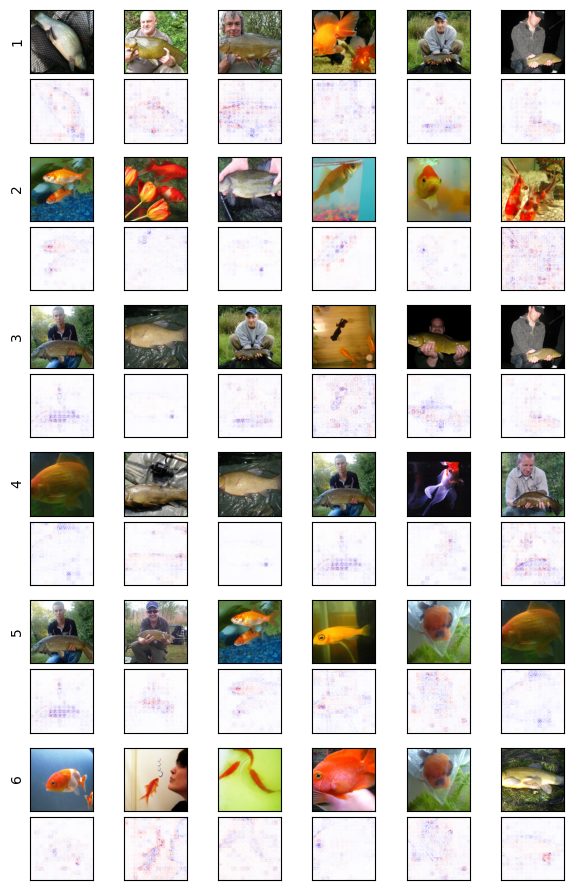

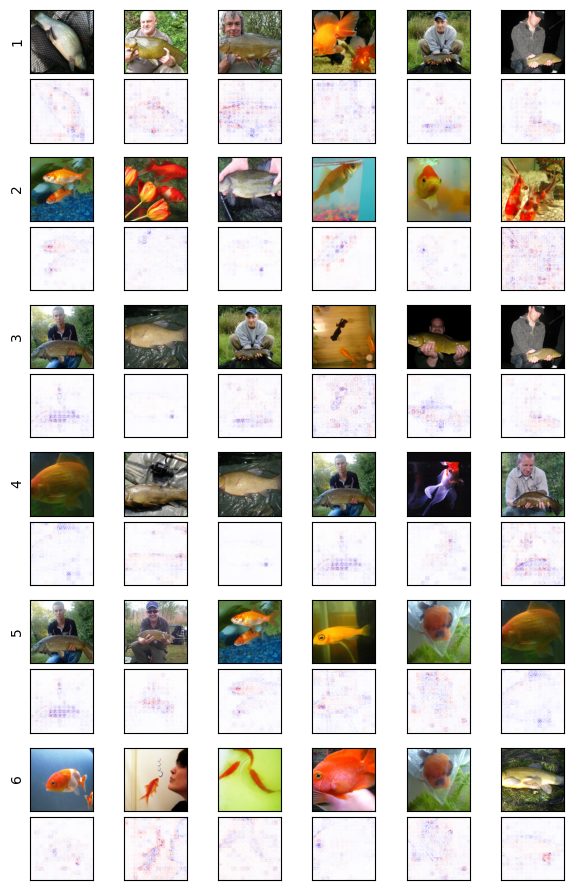

In [ ]:
%matplotlib inline
from crp.image import plot_grid


ref_c = fv.get_max_reference(
    concept_ids=[1, 2, 3, 4, 5, 6],
    layer_name="encoder.layers.encoder_layer_10.self_attention",
    mode="relevance",
    r_range=(0, 6),
    composite=composite,
)

plot_grid(ref_c, figsize=(6, 9), padding=False)

The grid above shows 6 reference images (columns) for each of 6 attention heads (rows) in layer 10. Each image is overlaid with its conditional heatmap: red regions contribute positively to the head's activation, blue regions suppress it.

**Observations:**
- Different heads specialise in different semantic concepts despite operating at the same depth — one head may focus on elongated body shapes, another on background textures or fine colour patterns.
- The heatmaps are relatively spread over the object of interest in late layers because the residual pathway aggregates global context before attention re-weighting.

As noted in the CRP paper, the last layer is sometimes dominated by a single class-token aggregation head. Moving one block earlier (layer 10) often exposes more diverse and interpretable head specialisations.

### Mid Layers — Structured, Compositional Features

In the middle of the network (blocks 6–9) heads begin to encode semantically meaningful part-level features: limbs, faces, distinct surface regions. The heatmaps here are often more spatially focused than in late layers.

In [ ]:
%matplotlib inline
from crp.image import plot_grid

ref_layer9 = fv.get_max_reference(
    concept_ids=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    layer_name="encoder.layers.encoder_layer_9.self_attention",
    mode="relevance",
    r_range=(0, 4),
    composite=composite,
)

plot_grid(ref_layer9, figsize=(8, 12), padding=False)

Compare these reference images with those from layer 11. At layer 9:
- Heatmaps tend to highlight **specific sub-regions** of objects (a paw, a beak, a wing pattern) rather than the whole object.
- The diversity across heads is higher — it is easier to find heads that specialise in visually distinct features.

### Early Layers — Texture and Low-Level Patterns

In the first few blocks (0–3), ViT attention heads operate close to the raw patch embeddings and tend to detect low-level visual patterns: edges, high-frequency textures, colour blobs. Reference images from these layers frequently show repeated local motifs rather than whole objects.

In [ ]:
%matplotlib inline
from crp.image import plot_grid

ref_layer3 = fv.get_max_reference(
    concept_ids=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    layer_name="encoder.layers.encoder_layer_3.self_attention",
    mode="relevance",
    r_range=(0, 4),
    composite=composite,
)

plot_grid(ref_layer3, figsize=(8, 12), padding=False)

Notice how early-layer reference images are often drawn from many different ImageNet classes — the same low-level texture or colour pattern appears across unrelated categories. This is the transformer analogue of the shallow CNN filters that detect generic edges and colour gradients rather than object-class-specific features.

## 5. Class-Level Statistics

`fv.compute_stats(concept_id, layer_name, mode, top_N, norm)` aggregates the per-head index across the stored class labels and returns the `top_N` ImageNet classes for which each head receives the most relevance. This tells us *which classes rely on a given head the most*.

`fv.get_stats_reference(concept_id, layer_name, targets, mode, r_range, composite)` then retrieves the most relevant reference images **per class** — increasing the diversity of visualizations compared to the unconditional `get_max_reference`.

In [ ]:
# Find which ImageNet classes rely most on head 3 in encoder layer 9
head_id = 3
layer = "encoder.layers.encoder_layer_9.self_attention"

targets, rel_scores = fv.compute_stats(head_id, layer, "relevance", top_N=5, norm=True)
print(f"Top-5 classes for head {head_id} in {layer}:")
for t, r in zip(targets, rel_scores):
    print(f"  class {int(t):4d}  norm-relevance = {float(r):.3f}")

In [ ]:
# Retrieve the most relevant images PER CLASS for this head
ref_stats = fv.get_stats_reference(
    concept_id=head_id,
    layer_name=layer,
    targets=targets,
    mode="relevance",
    r_range=(0, 5),
    composite=composite,
)

plot_grid(ref_stats, figsize=(7, 6), padding=False)

Each row in the grid above corresponds to one of the top-5 classes for head 3 in layer 9, and each column is one of the 5 most representative images of that class for this head. The heatmaps show which image regions the head focuses on for each class.

This class-stratified view is useful because it reveals:
- Whether a head is **class-specific** (strong relevance concentrated in one or two classes) or **class-agnostic** (relevance spread across many semantically unrelated classes).
- Whether a head detects a **visual property** (e.g. a texture pattern that appears in many classes) or an **object category** (e.g. only dogs or only birds).

In deeper layers, heads tend to be more class-specific; in shallower layers, heads are more class-agnostic, consistent with the hierarchical feature extraction picture.